# Model Comparison: Vanilla vs Fine-Tuned MatchFormer
For a single random pair, pick one query point in image 0 and show:
1. Epipolar line on image 1
2. Coarse confidence heatmap for that point (both models)
3. Where each model places its match vs GT

In [50]:
import os, sys

# Clear any cached failed imports
for mod in list(sys.modules):
    if mod == 'config' or mod.startswith('config.'):
        del sys.modules[mod]

os.chdir('/Users/siddharthraj/classes/cv/cv_final/MatchFormer')
if '/Users/siddharthraj/classes/cv/cv_final/MatchFormer' not in sys.path:
    sys.path.insert(0, '/Users/siddharthraj/classes/cv/cv_final/MatchFormer')
print('CWD:', os.getcwd())

CWD: /Users/siddharthraj/classes/cv/cv_final/MatchFormer


In [51]:
import os, sys, cv2, torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from einops import rearrange

# Add MatchFormer root to path
sys.path.insert(0, '/Users/siddharthraj/classes/cv/cv_final/MatchFormer')

from config.defaultmf import get_cfg_defaults
from model.lightning_loftr import PL_LoFTR
from model.datasets.scannet_simple import ScanNetSimpleDataset
from gt_epipolar import compute_fundamental_matrix

In [52]:
# ── Config ──────────────────────────────────────────────────────────────
DATA_DIR = '../data/scannet_format/MH_05'  # change as needed
VANILLA_CKPT = 'model/weights/indoor-lite-LA.ckpt'
FINETUNED_CKPT = 'phase2/weights/good-1.ckpt'    # change to your checkpoint

FRAME_GAP = 20
SPLIT_MODE = 'random'   # 'sequential' or 'random'
SPLIT_SEED = 42
PAIR_INDEX = None        # None = random, or set an int to pick a specific pair

# Device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


In [53]:
# ── Load dataset (test split) ──────────────────────────────────────────
val_ds = ScanNetSimpleDataset(
    DATA_DIR, frame_gap=FRAME_GAP, split='test', split_ratio=0.9,
    split_mode=SPLIT_MODE, split_seed=SPLIT_SEED
)
print(f'Test pairs: {len(val_ds)}')

  Scenes found: 1 (split=test, ratio=0.9, mode=random)
    scannet_format: 2253 pairs
  Total pairs: 226
Test pairs: 226


In [54]:
# ── Load models ────────────────────────────────────────────────────────
config = get_cfg_defaults()
config.MATCHFORMER.BACKBONE_TYPE = 'litela'
config.MATCHFORMER.SCENS = 'indoor'
config.MATCHFORMER.RESOLUTION = (8, 4)
config.MATCHFORMER.COARSE.D_MODEL = 192
config.MATCHFORMER.COARSE.D_FFN = 192

model_vanilla = PL_LoFTR(config, pretrained_ckpt=VANILLA_CKPT).to(DEVICE).eval()
model_finetuned = PL_LoFTR(config, pretrained_ckpt=FINETUNED_CKPT).to(DEVICE).eval()
print('Models loaded.')

2026-04-08 19:08:06.593 | INFO     | model.lightning_loftr:__init__:54 - Load 'model/weights/indoor-lite-LA.ckpt' as pretrained checkpoint
2026-04-08 19:08:06.595 | INFO     | model.lightning_loftr:__init__:87 - Trainable params: 13,144,320 / 20,256,704 (64.9%) — AttentionBlock3, AttentionBlock4, fine FPN head (BN frozen)
2026-04-08 19:08:07.438 | INFO     | model.lightning_loftr:__init__:54 - Load 'phase2/weights/good-1.ckpt' as pretrained checkpoint
2026-04-08 19:08:07.440 | INFO     | model.lightning_loftr:__init__:87 - Trainable params: 13,144,320 / 20,256,704 (64.9%) — AttentionBlock3, AttentionBlock4, fine FPN head (BN frozen)


Models loaded.


In [55]:
# ── Helper: run model and capture conf_matrix + matches ────────────────
@torch.no_grad()
def run_model(model, img0, img1, thr=0.2):
    """Returns mkpts0, mkpts1, mconf, conf_matrix, (H_c, W_c)."""
    data = {
        'image0': img0.unsqueeze(0).to(DEVICE),
        'image1': img1.unsqueeze(0).to(DEVICE),
    }
    old_thr = model.matcher.coarse_matching.thr
    model.matcher.coarse_matching.thr = thr
    model.matcher(data)
    model.matcher.coarse_matching.thr = old_thr

    mkpts0 = data['mkpts0_f'].cpu().numpy()
    mkpts1 = data['mkpts1_f'].cpu().numpy()
    mconf = data['mconf'].cpu().numpy() if 'mconf' in data else np.ones(len(mkpts0))
    conf_matrix = data['conf_matrix'][0].cpu()  # [L, S]
    hw_c = (data['hw0_c'][0].item() if isinstance(data['hw0_c'][0], torch.Tensor) else data['hw0_c'][0],
            data['hw0_c'][1].item() if isinstance(data['hw0_c'][1], torch.Tensor) else data['hw0_c'][1])
    return mkpts0, mkpts1, mconf, conf_matrix, hw_c

In [56]:
# ── Helper: coarse heatmap for a target point ──────────────────────────
def get_heatmap_for_point(conf_matrix, target_xy, hw_c, hw_img=(480, 640)):
    """
    Given a target point (x, y) in image 0 pixel coords,
    return the coarse confidence heatmap over image 1.
    
    conf_matrix: [L, S] where L = H_c * W_c (img0), S = H_c * W_c (img1)
    Returns: [H_c, W_c] heatmap (confidence of each img1 cell given the img0 cell)
    """
    H_c, W_c = hw_c
    H_img, W_img = hw_img
    stride = H_img // H_c

    # Convert pixel coord to coarse grid index
    cx = int(round(target_xy[0] / stride))
    cy = int(round(target_xy[1] / stride))
    cx = min(max(cx, 0), W_c - 1)
    cy = min(max(cy, 0), H_c - 1)
    flat_idx = cy * W_c + cx

    heatmap = conf_matrix[flat_idx].reshape(H_c, W_c).numpy()
    return heatmap, (cx * stride + stride // 2, cy * stride + stride // 2)

Pair: frames 1082 / 1102
Query point in img0: (480.0, 344.0)
Vanilla: 2256 matches  |  Fine-tuned: 0 matches


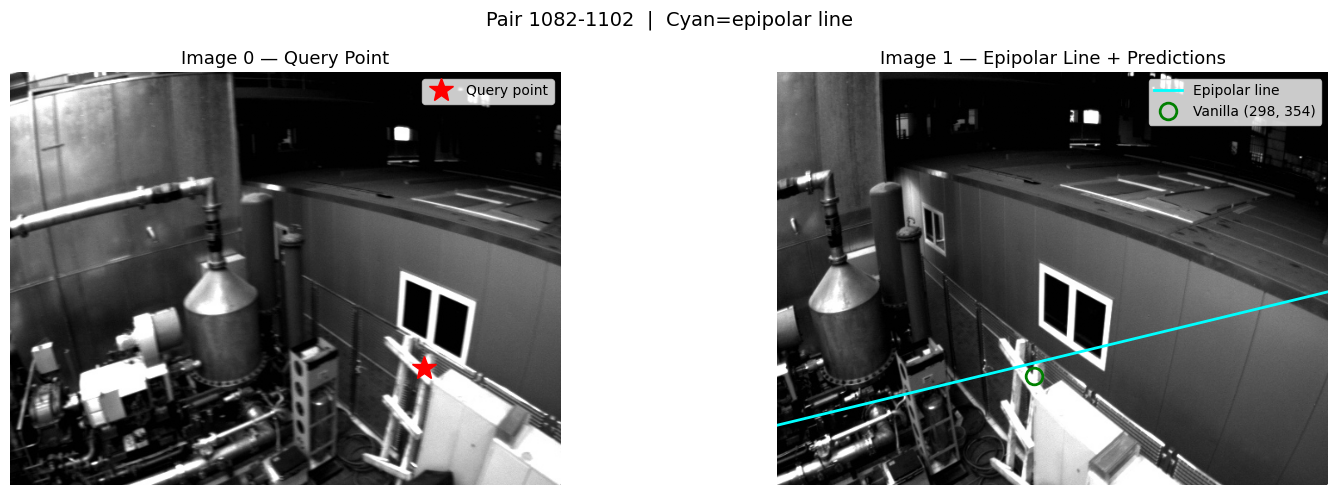

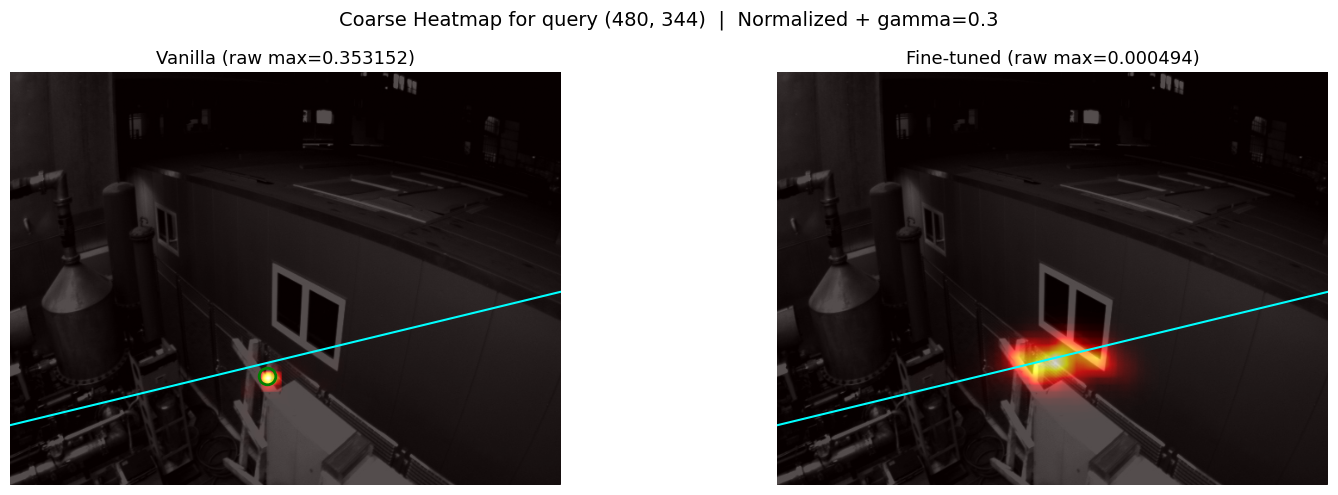

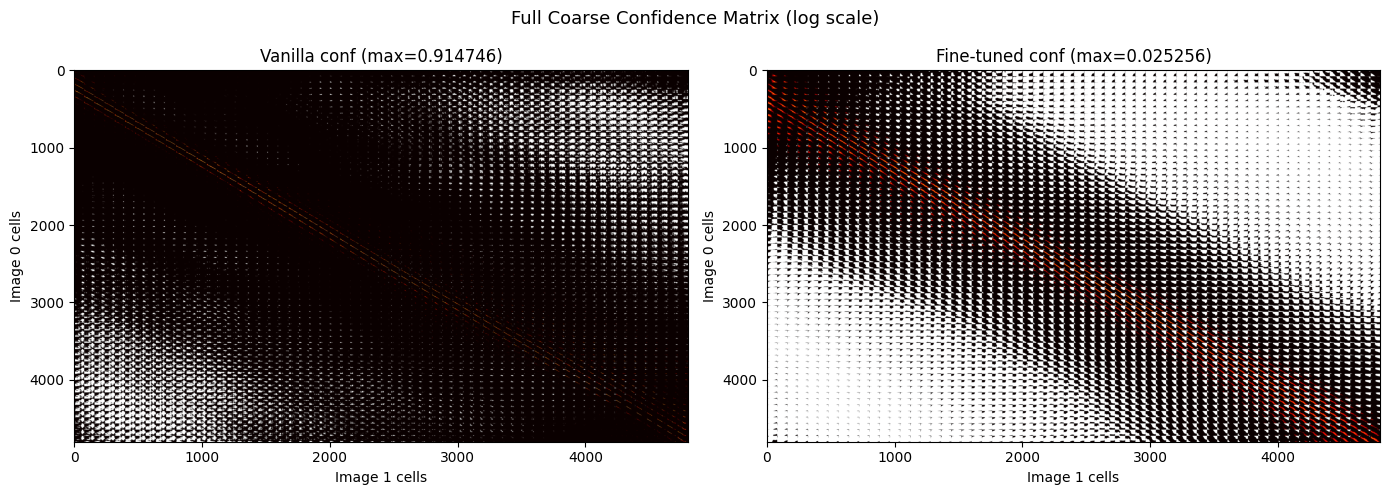

In [58]:
# ── Single-point comparison: epipolar line + heatmap + match ───────────
from matplotlib.colors import PowerNorm

def draw_epipolar_line(ax, F_mat, pt, img_shape, color='cyan', lw=1.5):
    """Draw the epipolar line on img1 corresponding to pt in img0."""
    H, W = img_shape[:2]
    p = np.array([pt[0], pt[1], 1.0])
    l = F_mat @ p
    a, b, c = l
    if abs(b) > 1e-8:
        x0, x1_end = 0, W
        y0 = -(a * x0 + c) / b
        y1 = -(a * x1_end + c) / b
    else:
        y0, y1 = 0, H
        x0 = -(b * y0 + c) / a
        x1_end = -(b * y1 + c) / a
    ax.plot([x0, x1_end], [y0, y1], color=color, linewidth=lw, label='Epipolar line')
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)

def find_nearest_match(mkpts0, mkpts1, query_pt):
    if len(mkpts0) == 0:
        return None, None
    dists = np.linalg.norm(mkpts0 - query_pt, axis=1)
    idx = np.argmin(dists)
    return mkpts0[idx], mkpts1[idx]

# ── Pick a random pair ─────────────────────────────────────────────────
rng = np.random.RandomState(45)
idx = PAIR_INDEX if PAIR_INDEX is not None else rng.randint(0, len(val_ds))
item = val_ds[idx]

img0_np = item['image0'].squeeze(0).numpy()
img1_np = item['image1'].squeeze(0).numpy()
T0, T1 = item['T0'].numpy(), item['T1'].numpy()
K = item['K'].numpy()
pair_name = item.get('pair_names', (str(idx), ''))

F_mat = compute_fundamental_matrix(T0, T1, K, K)

mk0_v, mk1_v, _, conf_v, hw_c = run_model(model_vanilla, item['image0'], item['image1'], thr=0.2)
mk0_f, mk1_f, _, conf_f, _    = run_model(model_finetuned, item['image0'], item['image1'], thr=0.2)

if len(mk0_v) > 0:
    query_idx = rng.randint(0, len(mk0_v))
    query_pt = mk0_v[query_idx]
else:
    query_pt = np.array([320.0, 240.0])

print(f'Pair: frames {pair_name[0]} / {pair_name[1]}')
print(f'Query point in img0: ({query_pt[0]:.1f}, {query_pt[1]:.1f})')
print(f'Vanilla: {len(mk0_v)} matches  |  Fine-tuned: {len(mk0_f)} matches')

v_src, v_dst = find_nearest_match(mk0_v, mk1_v, query_pt)
f_src, f_dst = find_nearest_match(mk0_f, mk1_f, query_pt)

# ── Plot 1: Image pair with query point, epipolar line, and matches ───
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(img0_np, cmap='gray')
axes[0].plot(query_pt[0], query_pt[1], 'r*', markersize=18, label='Query point')
axes[0].set_title('Image 0 — Query Point', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].axis('off')

axes[1].imshow(img1_np, cmap='gray')
draw_epipolar_line(axes[1], F_mat, query_pt, img1_np.shape, color='cyan', lw=2)
if v_dst is not None:
    axes[1].plot(v_dst[0], v_dst[1], 'go', markersize=12, markeredgewidth=2,
                 markerfacecolor='none', label=f'Vanilla ({v_dst[0]:.0f}, {v_dst[1]:.0f})')
if f_dst is not None:
    axes[1].plot(f_dst[0], f_dst[1], 'ms', markersize=12, markeredgewidth=2,
                 markerfacecolor='none', label=f'Fine-tuned ({f_dst[0]:.0f}, {f_dst[1]:.0f})')
axes[1].set_title('Image 1 — Epipolar Line + Predictions', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].axis('off')

plt.suptitle(f'Pair {pair_name[0]}-{pair_name[1]}  |  Cyan=epipolar line', fontsize=14)
plt.tight_layout()
plt.show()

# ── Plot 2: Coarse confidence heatmaps (per-map normalized) ──────────
hm_v, _ = get_heatmap_for_point(conf_v, query_pt, hw_c)
hm_f, _ = get_heatmap_for_point(conf_f, query_pt, hw_c)

# Normalize each heatmap to [0, 1] so structure is visible
def normalize_heatmap(hm):
    mn, mx = hm.min(), hm.max()
    if mx - mn < 1e-10:
        return np.zeros_like(hm)
    return (hm - mn) / (mx - mn)

hm_v_norm = normalize_heatmap(hm_v)
hm_f_norm = normalize_heatmap(hm_f)

hm_v_up = cv2.resize(hm_v_norm, (640, 480), interpolation=cv2.INTER_LINEAR)
hm_f_up = cv2.resize(hm_f_norm, (640, 480), interpolation=cv2.INTER_LINEAR)

# Apply power scaling (gamma < 1 boosts low values to reveal structure)
gamma = 0.3
hm_v_up = np.power(hm_v_up, gamma)
hm_f_up = np.power(hm_f_up, gamma)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(img1_np, cmap='gray')
axes[0].imshow(hm_v_up, cmap='hot', alpha=0.7, vmin=0, vmax=1)
draw_epipolar_line(axes[0], F_mat, query_pt, img1_np.shape, color='cyan', lw=1.5)
if v_dst is not None:
    axes[0].plot(v_dst[0], v_dst[1], 'go', markersize=12, markeredgewidth=2, markerfacecolor='none')
axes[0].set_title(f'Vanilla (raw max={hm_v.max():.6f})', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img1_np, cmap='gray')
axes[1].imshow(hm_f_up, cmap='hot', alpha=0.7, vmin=0, vmax=1)
draw_epipolar_line(axes[1], F_mat, query_pt, img1_np.shape, color='cyan', lw=1.5)
if f_dst is not None:
    axes[1].plot(f_dst[0], f_dst[1], 'ms', markersize=12, markeredgewidth=2, markerfacecolor='none')
axes[1].set_title(f'Fine-tuned (raw max={hm_f.max():.6f})', fontsize=13)
axes[1].axis('off')

plt.suptitle(f'Coarse Heatmap for query ({int(query_pt[0])}, {int(query_pt[1])})  |  Normalized + gamma={gamma}', fontsize=14)
plt.tight_layout()
plt.show()

# ── Plot 3: Full confidence matrix side-by-side (log scale) ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conf_v_np = conf_v.numpy()
conf_f_np = conf_f.numpy()

# Log scale to reveal structure in sparse confidence matrices
from matplotlib.colors import LogNorm
vmin_log = 1e-7
vmax_log = max(conf_v_np.max(), conf_f_np.max())

axes[0].imshow(conf_v_np, aspect='auto', cmap='hot', norm=LogNorm(vmin=vmin_log, vmax=vmax_log))
axes[0].set_title(f'Vanilla conf (max={conf_v_np.max():.6f})', fontsize=12)
axes[0].set_xlabel('Image 1 cells'); axes[0].set_ylabel('Image 0 cells')
axes[1].imshow(conf_f_np, aspect='auto', cmap='hot', norm=LogNorm(vmin=vmin_log, vmax=vmax_log))
axes[1].set_title(f'Fine-tuned conf (max={conf_f_np.max():.6f})', fontsize=12)
axes[1].set_xlabel('Image 1 cells'); axes[1].set_ylabel('Image 0 cells')
plt.suptitle('Full Coarse Confidence Matrix (log scale)', fontsize=13)
plt.tight_layout()
plt.show()